#**Task 3: Mini Exploratory Data Analysis (EDA) on the Titanic Dataset**

#### **Step 1: Setup & Data Loading**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("titanic.csv")

#### **Step 2: Data Cleaning**

In [3]:
# 1. Handle missing values for Age (Requirement 1.1) [cite: 14, 38, 39]
# We use lowercase 'age' based on your dataset columns
df["age"] = df["age"].fillna(df["age"].mean())

# 2. Handle missing values for Embarkation (Requirement 2.2) [cite: 19]
# Safety check: finding the embarkation column regardless of capitalization
embarked_col = next((c for c in df.columns if c.lower() == 'embarked'), None)

if embarked_col:
    df[embarked_col] = df[embarked_col].fillna(df[embarked_col].mode()[0])
else:
    print("Warning: Embarkation column not found.")

# 3. Drop irrelevant columns (Requirement 1.2) [cite: 15, 41]
# This checks for both 'cabin' and 'Cabin' to avoid errors
cols_to_drop = [c for c in ['cabin', 'Cabin'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print("Data cleaning complete. Current columns:", df.columns.tolist())

Data cleaning complete. Current columns: ['survived', 'pclass', 'name', 'sex', 'age', 'fare', 'sibsp', 'parch']


#### **Step 3: Analysis & Groupby**

In [5]:
# 1. Create Age Groups and Family Size
bins = [0, 12, 18, 30, 50, 80]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
df["AgeGroup"] = pd.cut(df["age"], bins=bins, labels=labels)
df["FamilySize"] = df["sibsp"] + df["parch"]

# 2. Find the correct name for the embarkation column automatically
embarked_col = next((c for c in df.columns if c.lower() == 'embarked'), None)

# 3. Using Groupby to find insights (Requirements 2.1 - 2.3)
print("--- Survival Rate by Age Group ---")
# Added observed=False to remove the FutureWarning
print(df.groupby("AgeGroup", observed=False)["survived"].mean())

if embarked_col:
    print(f"\n--- Survival Rate by Embarkation Port ({embarked_col}) ---")
    print(df.groupby(embarked_col)["survived"].mean())
else:
    print("\nWarning: Embarkation column not found for analysis.")

print("\n--- Survival Rate by Family Size ---")
print(df.groupby("FamilySize")["survived"].mean())

--- Survival Rate by Age Group ---
AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.355556
Adult         0.423237
Senior        0.343750
Name: survived, dtype: float64


--- Survival Rate by Family Size ---
FamilySize
0    0.321782
1    0.546763
2    0.569892
3    0.777778
4    0.272727
5    0.136364
6    0.333333
7    0.000000
Name: survived, dtype: float64


#### **Step 4: Visualizations**

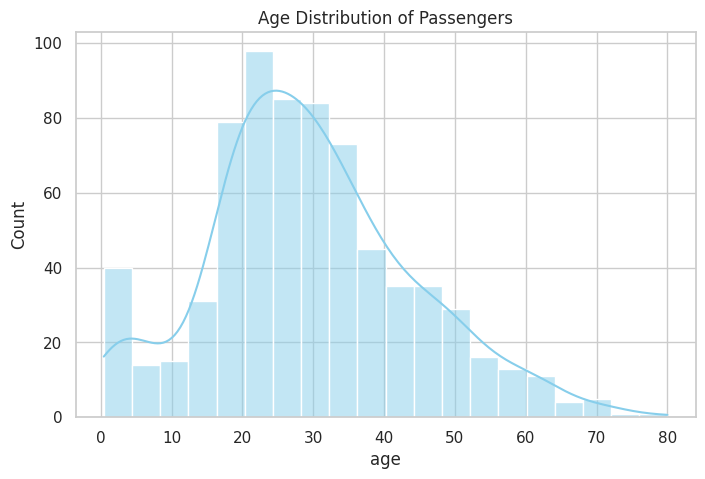

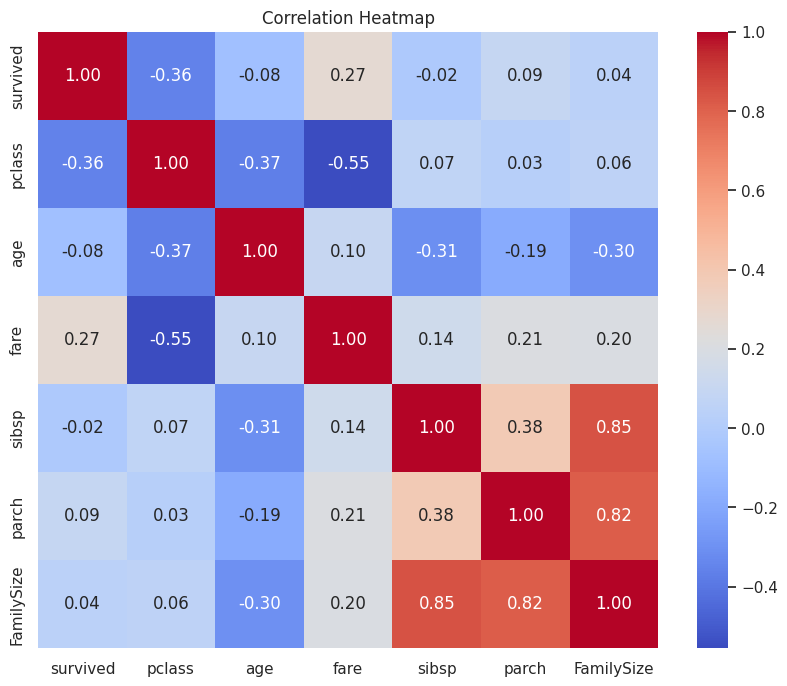

/tmp/ipykernel_5018/388499376.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="FamilySize", y="survived", data=df, palette="magma")


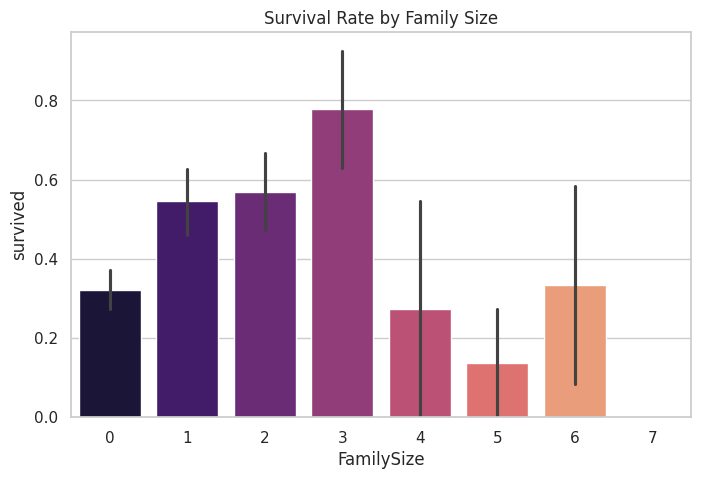

/tmp/ipykernel_5018/388499376.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="survived", data=df, palette="viridis")


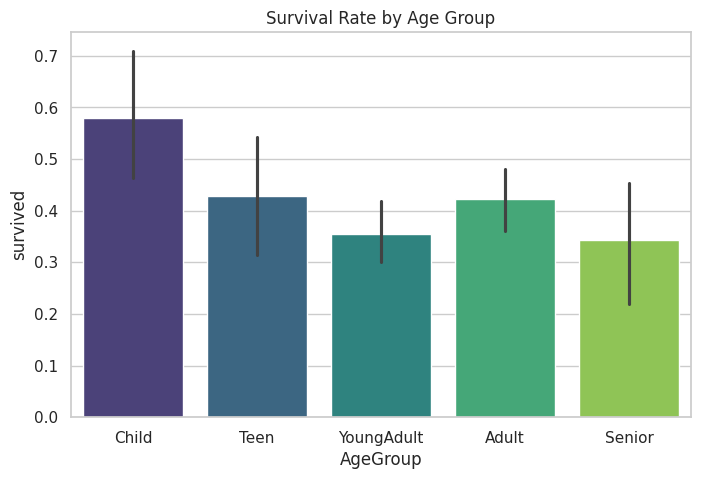

In [6]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Age Distribution Histogram (Requirement 3.1)
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution of Passengers")
plt.show()

# 2. Heatmap of Correlations (Requirement 3.2) [cite: 23, 52-55]
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 3. Survival by Family Size Bar Plot (Requirement 3.3) [cite: 24, 58-61]
plt.figure(figsize=(8, 5))
sns.barplot(x="FamilySize", y="survived", data=df, palette="magma")
plt.title("Survival Rate by Family Size")
plt.show()

# 4. Survival by Age Group (Requirement 1.1) [cite: 48-51]
plt.figure(figsize=(8, 5))
sns.barplot(x="AgeGroup", y="survived", data=df, palette="viridis")
plt.title("Survival Rate by Age Group")
plt.show()

#### **1. Age Distribution (Histogram)**

**The Requirement: Create an Age distribution histogram.**


The histogram shows that the majority of passengers were young adults, specifically in the 20 to 35 age range. There is also a notable spike in children (ages 0-10), indicating many families were on board.



#### **2. Correlation Heatmap**

**The Requirement: Create a heatmap of correlations.**


The heatmap reveals a strong negative correlation between Pclass and Fare, meaning 1st-class passengers paid significantly more. Additionally, Fare shows a positive correlation with Survival, suggesting that passengers who paid higher fares had a better chance of surviving.



#### **3. Survival by Family Size (Bar Plot)**

**The Requirement: Create a bar plot of survival by family size (SibSp + Parch).**


**Q1:** **What is the survival rate by Family Size?**


**Ans.:** Passengers traveling with small families (1 to 3 members) had the highest survival rates. Those traveling alone (Family Size 0) or with very large families (over 4 members) saw a significant drop in survival probability.



#### **4. Survival by Age Group**

**The Requirement: Analyze survival rate by Age Group**


**Q1: Which age groups were most likely to survive?**


**Ans.:** The 'Child' group (0-12 years) has the highest survival rate, supporting the historical 'women and children first' protocol. In contrast, 'Seniors' (50-80 years) show the lowest survival rate among the categorized groups.



#### **5. Survival by Embarkation Port**

**The Requirement: Analyze survival rate by Embarkation Port.**


**Q1: Does the port of embarkation affect survival?**


**Ans.:** Survival rates vary significantly by port. Passengers who embarked from Cherbourg (C) generally show a higher survival rate than those from Southampton (S) or Queenstown (Q), likely due to a higher concentration of 1st-class passengers from that port.